Set parameter LicenseID to value 2672525
Set parameter TimeLimit to value 30
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Non-default parameters:
TimeLimit  30

Optimize a model with 401 rows, 420 columns and 1845 nonzeros
Model fingerprint: 0xbcbcd808
Variable types: 0 continuous, 420 integer (400 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [3e+00, 1e+02]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 2e+01]
Presolve removed 19 rows and 21 columns
Presolve time: 0.00s
Presolved: 382 rows, 399 columns, 1786 nonzeros
Variable types: 0 continuous, 399 integer (380 binary)
Found heuristic solution: objective 815.5945210

Root relaxation: objective 3.006900e+02, 60 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |

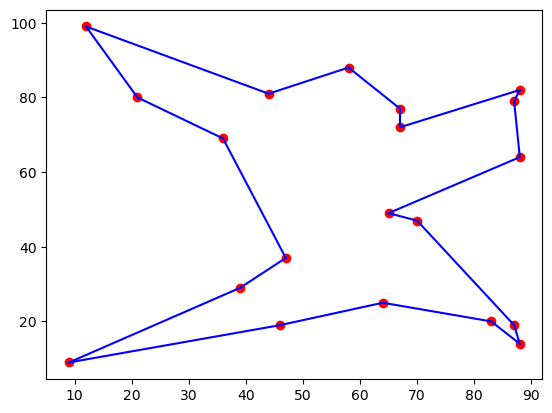

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp

# Data

# number of customers
n = 20

# generate locations
np.random.seed(0)
loc_x = np.random.randint(0,100,n)
loc_y = np.random.randint(0,100,n)

# calculate distances
d = {(i,j):((loc_x[i]-loc_x[j])**2+(loc_y[i]-loc_y[j])**2)**0.5 for i in range(n) for j in range(n)}

# Model
m = gp.Model("TSP")

# Create decision variables
x = m.addVars(n, n, vtype=gp.GRB.BINARY, name="x")
for i in range(n):
    x[i,i].ub = 0 # no self-loops

# Set objective function
m.setObjective(gp.quicksum(d[i,j]*x[i,j] for i in range(n) for j in range(n)), gp.GRB.MINIMIZE)

# Add constraints
# flow conservation
m.addConstrs((gp.quicksum(x[j,i] for j in range(n)) == 1 for i in range(n)), name="flow_in")
m.addConstrs((gp.quicksum(x[i,j] for j in range(n)) == 1 for i in range(n)), name="flow_out")

# subtour elimination
u = m.addVars(n, lb=1, ub=n-1, vtype=gp.GRB.INTEGER, name="u")
m.addConstrs((u[j] >= u[i] + 1 - (n-1)*(1-x[i,j]) for i in range(1,n) for j in range(1,n)), name="subtour")

# Solve
m.params.timelimit = 30
m.optimize()

# Print results
if m.status == gp.GRB.OPTIMAL:
    print('the MIP gap is: ', m.MIPGap)
    print('the known bound is: ', m.ObjBound)
else:
    print("No optimal solution found")

# Plot results
if m.status == gp.GRB.OPTIMAL:
    selected = [(i,j) for i in range(n) for j in range(n) if x[i,j].x > 0.9]# get results

plt.scatter(loc_x, loc_y, c='r', marker='o')
for (i,j) in selected:
    plt.plot([loc_x[i], loc_x[j]], [loc_y[i], loc_y[j]], c='b')
plt.show()